In [2]:
words = open('names.txt', 'r').read().splitlines()

In [3]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [4]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1,ch2 in zip(chs,chs[1:]):
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram, 0) + 1

b

{('<S>', 'e'): 1531,
 ('e', 'm'): 769,
 ('m', 'm'): 168,
 ('m', 'a'): 2590,
 ('a', '<E>'): 6640,
 ('<S>', 'o'): 394,
 ('o', 'l'): 619,
 ('l', 'i'): 2480,
 ('i', 'v'): 269,
 ('v', 'i'): 911,
 ('i', 'a'): 2445,
 ('<S>', 'a'): 4410,
 ('a', 'v'): 834,
 ('v', 'a'): 642,
 ('<S>', 'i'): 591,
 ('i', 's'): 1316,
 ('s', 'a'): 1201,
 ('a', 'b'): 541,
 ('b', 'e'): 655,
 ('e', 'l'): 3248,
 ('l', 'l'): 1345,
 ('l', 'a'): 2623,
 ('<S>', 's'): 2055,
 ('s', 'o'): 531,
 ('o', 'p'): 95,
 ('p', 'h'): 204,
 ('h', 'i'): 729,
 ('<S>', 'c'): 1542,
 ('c', 'h'): 664,
 ('h', 'a'): 2244,
 ('a', 'r'): 3264,
 ('r', 'l'): 413,
 ('l', 'o'): 692,
 ('o', 't'): 118,
 ('t', 't'): 374,
 ('t', 'e'): 716,
 ('e', '<E>'): 3983,
 ('<S>', 'm'): 2538,
 ('m', 'i'): 1256,
 ('a', 'm'): 1634,
 ('m', 'e'): 818,
 ('<S>', 'h'): 874,
 ('r', 'p'): 14,
 ('p', 'e'): 197,
 ('e', 'r'): 1958,
 ('r', '<E>'): 1377,
 ('e', 'v'): 463,
 ('v', 'e'): 568,
 ('l', 'y'): 1588,
 ('y', 'n'): 1826,
 ('n', '<E>'): 6763,
 ('b', 'i'): 217,
 ('i', 'g'): 428,


In [5]:
import torch

In [6]:
N = torch.zeros((27,27), dtype=torch.int32)
N

tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],


In [7]:
chars = sorted(list(set(''.join(words))))

In [8]:
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0

In [9]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        N[stoi[ch1], stoi[ch2]] += 1

In [10]:
N

tensor([[   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
         1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
          134,  535,  929],
        [6640,  556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568,
         2528, 1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,
          182, 2050,  435],
        [ 114,  321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,
          103,    0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,
            0,   83,    0],
        [  97,  815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,
          116,    0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,
            3,  104,    4],
        [ 516, 1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,
           60,   30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,
            0,  317,    1],
        [3983,  679,  121,  153,  384, 1271,   82,

In [11]:
itos = {i:s for s,i in stoi.items()}

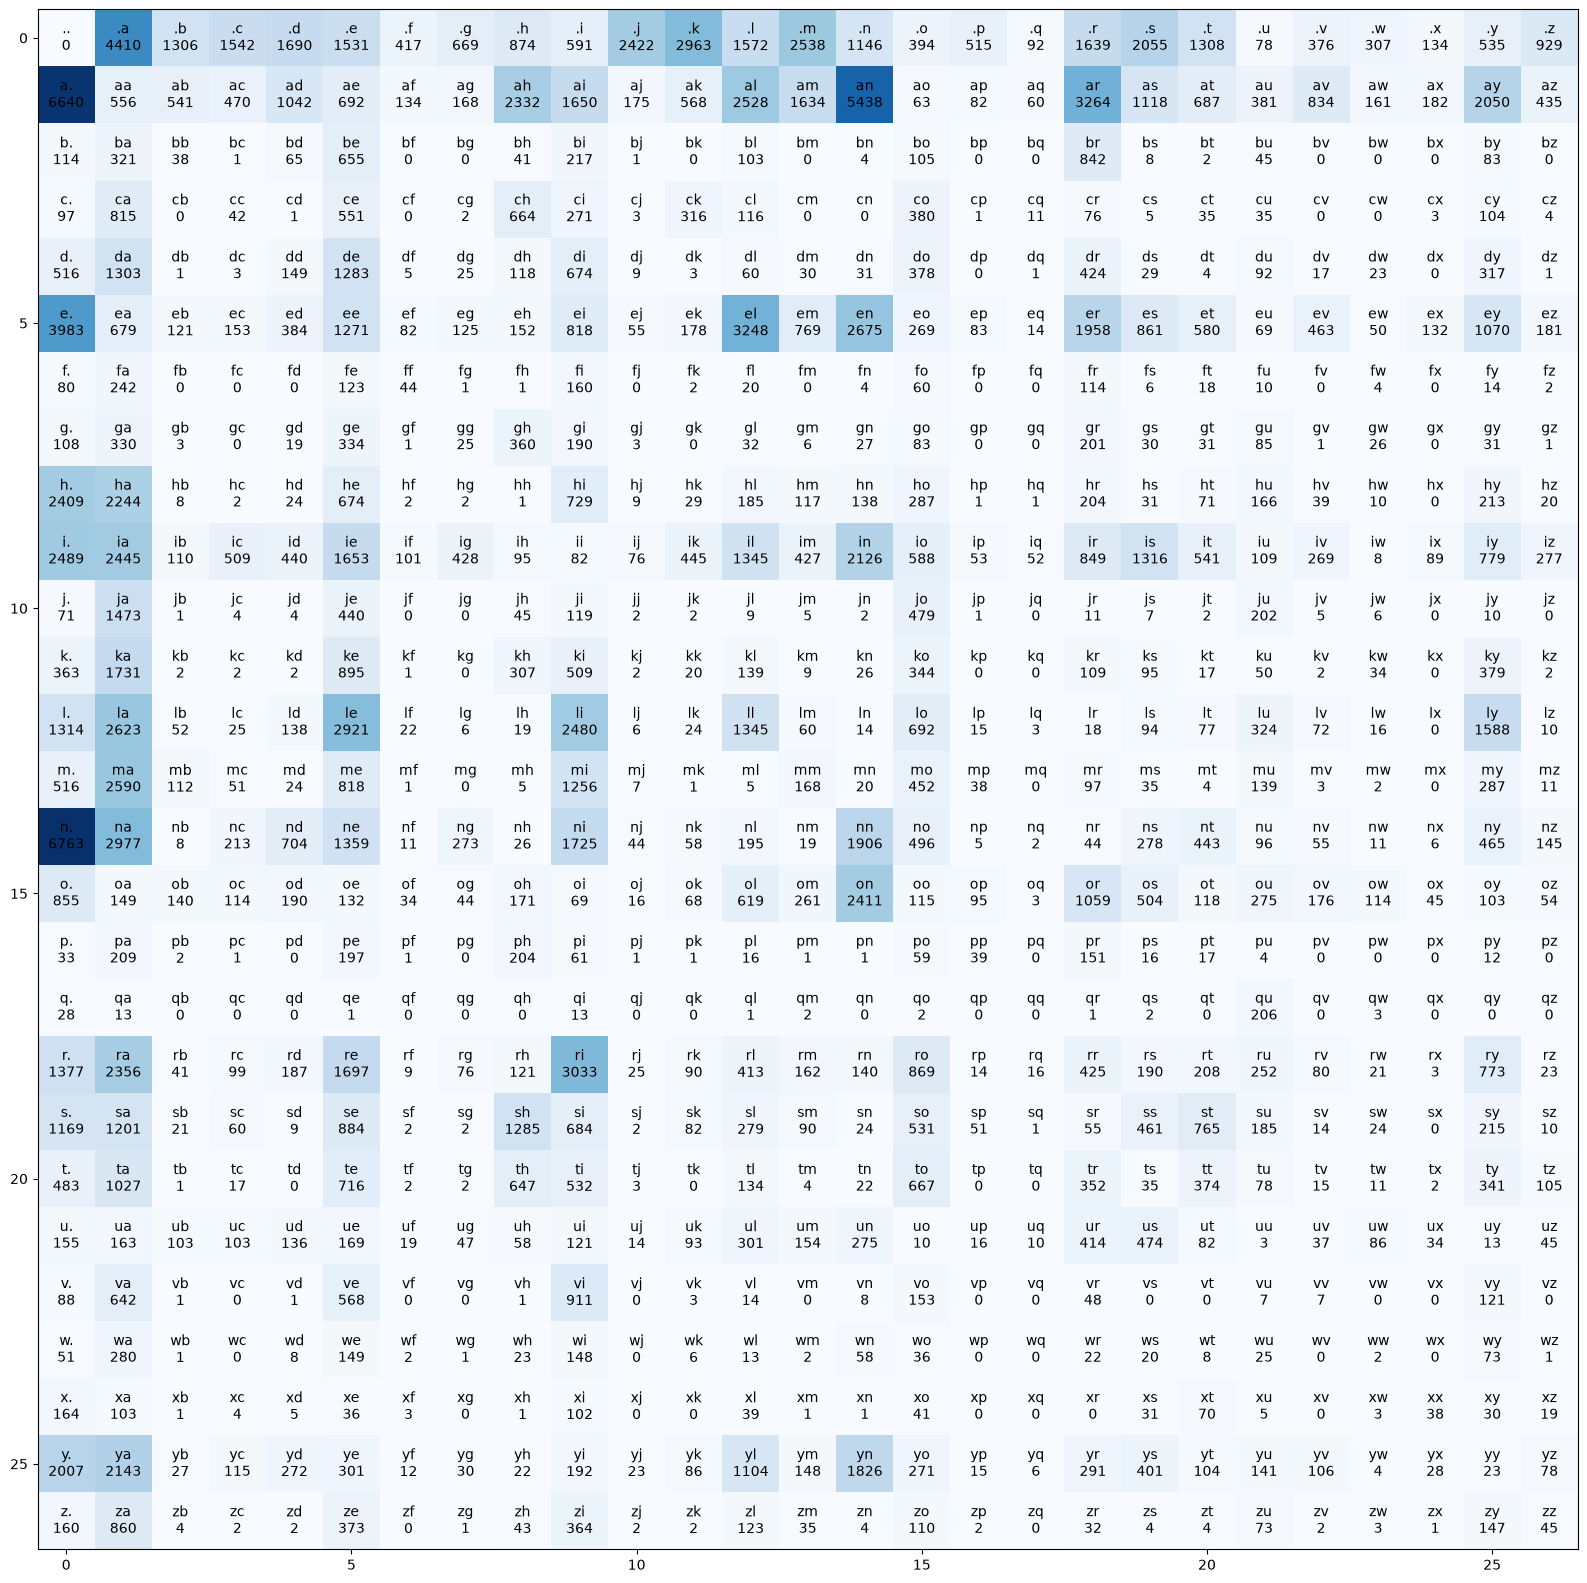

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20,20))
plt.imshow(N, cmap='Blues')
for i in range(0,27):
    for j in range(0,27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr + '\n' + str(N[i,j].item()), ha='center', va='center', color='black')

In [13]:
# p = N[0].float() / N[0].sum()
# p

P = (N+1).float()
P /= P.sum(1, keepdim=True)

In [14]:
g = torch.Generator().manual_seed(2147483647)
for i in range(200):
    out = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.
feniee.
zem.
deru.
firit.
gaikajahahbevare.
kiysthelenaririenah.
keen.
x.
al.
kal.
thavazeeromysos.
laitenimieegariseriyen.
k.
illeleldole.
meenisammigama.
mmin.
asharin.
alcalar.
jayn.
asaz.
selanely.
chay.
rana.
ai.
yviamisashougen.
l.
beyncaro.
allan.
annutetoradrilia.
rddeman.
me.
vifahevara.
jala.
j.
gh.
cryalan.
rlaylmacondo.
pera.
yd.
en.
aienossin.
me.
jancla.
tiesel.
jedahzynaleroneritotturiron.
cri.
alkismeamere.
morad.
lieintamaamnnf.
miayuleonteadajeya.
renari.
x.
keika.
s.
ynn.
miudawa.
chahan.
jondelie.
kedariza.
lha.
denoni.
kar.
kavanista.
kesorrlilaa.
lelike.
ssh.
drl.
rcagalaicalasion.
avallciny.
boh.
en.
caikeladeradefwiea.
fes.
malolela.
liy.
elan.
jalinain.
rmayoadish.
con.
alomaruikeee.
djhammy.
arileedistanahistl.
on.
iy.
riyeti.
kazla.
aus.
ckadsi.
lisakhylendeese.
ferah.
ri.
alsorayna.
a

In [26]:
n = 0
likelihood = 0.0
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        bigram = (ch1,ch2)
        prob = P[stoi[ch1], stoi[ch2]]
        likelihood += torch.log(prob)
        # print(f'bigram: {bigram}, prob: {prob.item()}, log_prob: {torch.log(prob).item()}')
        n += 1

neg_log_likelihood = -(likelihood/n)
print(f'Negative Log Likelihood: {neg_log_likelihood.item()}')


Negative Log Likelihood: 2.4543561935424805


In [27]:
print(f'Negative Log Likelihood: {neg_log_likelihood.item()}')

Negative Log Likelihood: 2.4543561935424805


In [30]:
xs, ys = [], []

for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [31]:
print(xs)
print(ys)

tensor([ 0,  5, 13, 13,  1])
tensor([ 5, 13, 13,  1,  0])


In [32]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

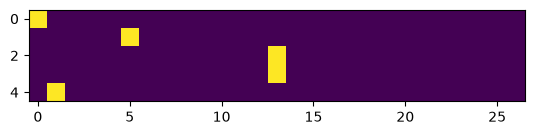

In [33]:
plt.imshow(xenc)

In [39]:
W = torch.randn((27, 27))
xenc @ W

tensor([[-0.0928,  0.5304,  0.1653,  0.3454, -1.3495, -0.2122,  0.0261, -1.4869,
         -1.2440,  0.2771,  0.9232,  2.5998, -0.3288, -0.3068, -0.1876, -2.0546,
          0.5287, -0.6548, -0.5536, -0.1678, -1.9984,  1.5859, -1.7844, -0.4715,
         -0.6133,  1.0013,  1.1448],
        [-0.9503,  0.2498,  1.2138,  0.3400,  0.3609, -0.8878, -0.7865,  0.7047,
         -0.4468,  1.4156,  1.1553,  0.4185, -0.4518,  1.4159, -0.3728, -0.0298,
          1.4026,  2.3445,  0.2033, -0.8680,  0.4793, -0.0106,  1.2173, -0.2890,
          0.4037,  0.6097,  0.1290],
        [ 1.8414,  1.9093,  0.4531, -0.2411, -1.8403, -0.1026,  0.3160, -0.7431,
         -0.3384, -0.2167, -0.8266, -0.2736, -0.0359, -0.5106, -0.9660, -1.1956,
         -0.1257, -0.7096, -1.0563,  0.4912,  0.6013, -0.3093, -0.6540, -1.2022,
         -0.1496,  0.1725, -0.2715],
        [ 1.8414,  1.9093,  0.4531, -0.2411, -1.8403, -0.1026,  0.3160, -0.7431,
         -0.3384, -0.2167, -0.8266, -0.2736, -0.0359, -0.5106, -0.9660, -1.1956

In [40]:
(xenc @ W).exp()

tensor([[ 0.9114,  1.6996,  1.1797,  1.4125,  0.2594,  0.8088,  1.0264,  0.2261,
          0.2882,  1.3193,  2.5173, 13.4605,  0.7198,  0.7358,  0.8290,  0.1281,
          1.6968,  0.5195,  0.5748,  0.8456,  0.1356,  4.8837,  0.1679,  0.6241,
          0.5416,  2.7219,  3.1417],
        [ 0.3866,  1.2838,  3.3661,  1.4050,  1.4346,  0.4115,  0.4554,  2.0233,
          0.6397,  4.1190,  3.1750,  1.5196,  0.6365,  4.1200,  0.6888,  0.9706,
          4.0659, 10.4277,  1.2255,  0.4198,  1.6150,  0.9895,  3.3780,  0.7490,
          1.4973,  1.8399,  1.1377],
        [ 6.3054,  6.7480,  1.5732,  0.7858,  0.1588,  0.9025,  1.3716,  0.4756,
          0.7129,  0.8052,  0.4375,  0.7606,  0.9648,  0.6001,  0.3806,  0.3025,
          0.8819,  0.4918,  0.3478,  1.6343,  1.8245,  0.7340,  0.5200,  0.3005,
          0.8611,  1.1883,  0.7622],
        [ 6.3054,  6.7480,  1.5732,  0.7858,  0.1588,  0.9025,  1.3716,  0.4756,
          0.7129,  0.8052,  0.4375,  0.7606,  0.9648,  0.6001,  0.3806,  0.3025

In [41]:
logits = xenc @ W #log counts
counts = logits.exp() # From log counts to counts

In [44]:
probs = counts / counts.sum(1, keepdim=True)

In [47]:
probs.sum(1, keepdim=True)

tensor([[1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000]])

In [51]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g)

In [52]:
xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
logits = xenc @ W # predict log-counts
counts = logits.exp() # counts, equivalent to N
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character

In [53]:

nlls = torch.zeros(5)
for i in range(5):
  # i-th bigram:
  x = xs[i].item() # input character index
  y = ys[i].item() # label character index
  print('--------')
  print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
  print('input to the neural net:', x)
  print('output probabilities from the neural net:', probs[i])
  print('label (actual next character):', y)
  p = probs[i, y]
  print('probability assigned by the net to the the correct character:', p.item())
  logp = torch.log(p)
  print('log likelihood:', logp.item())
  nll = -logp
  print('negative log likelihood:', nll.item())
  nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

--------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459])
label (actual next character): 5
probability assigned by the net to the the correct character: 0.012286250479519367
log likelihood: -4.3992743492126465
negative log likelihood: 4.3992743492126465
--------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
        0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
        0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472])
label (actual next character): 13
probability assigned by the net to the the correct character:

In [54]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

In [63]:
# forward pass [input x W = logits then exp(logits) = counts then normalize to get probabilities]
xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
logits = xenc @ W # predict log-counts
counts = logits.exp() # counts, equivalent to N
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
loss = -probs[torch.arange(5), ys].log().mean() #probabilities for next character for our dataset that we are training on

In [64]:
print(loss.item())

3.7291626930236816


In [65]:
# backward pass
W.grad = None # set to zero the gradient
loss.backward()

In [66]:
W.data -= 0.1 * W.grad

In [67]:
# create the dataset for training neural network
xs, ys = [], []
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True) # random weights with seed

number of examples:  228146


In [71]:
# gradient descent ~ we are tring to minimize the loss function by updating the weights of the neural network
for k in range(1):
  
  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
  logits = xenc @ W # predict log-counts
  counts = logits.exp() # counts, equivalent to N
  probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
  loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
  print(loss.item())
  
  # backward pass
  W.grad = None # set to zero the gradient
  loss.backward()
  
  # update
  W.data -= 3 * W.grad

2.506530284881592


In [72]:
# generate names from the trained model
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
  
  out = []
  ix = 0
  while True:
    
    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

cexze.
momasurailezityha.
konimittain.
llayn.
ka.
